In [1]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dataset.InterHand26M import InterHand26M
from dataset.InterHand26M.utils.mano import mano

Fix shapedirs bug of MANO


/home/renkaiwen/.conda/envs/sl_vit_cu118/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


# Dataset

In [2]:
transforms_test = transforms.Compose([
    transforms.Resize((224, 224))
])

dataset_train = InterHand26M(transforms_test, "test")
dataloader = torch.utils.data.DataLoader(dataset_train, batch_size=4)
print(dataset_train, dataloader)

loading annotations into memory...
Done (t=35.83s)
creating index...
index created!
<dataset.InterHand26M.InterHand26M.InterHand26M object at 0x7fbdc82983a0> <torch.utils.data.dataloader.DataLoader object at 0x7fbc03d9a950>


In [192]:
inputs_, targets_, meta_info_ = next(iter(dataloader))
bx = 2

In [193]:
inputs_.keys()  # img, {l,r}hand_img

def restore_nimg(img):
    # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = eps.rearrange(img, 'c h w -> h w c')
    
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    return img * std[None,None,:] + mean[None,None,:]

plt.imshow(restore_nimg(inputs_['rhand_img'][bx]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.4138582..1.4716449].


In [56]:
targets_.keys()

dict_keys(['joint_img', 'mano_joint_img', 'joint_cam', 'mano_mesh_cam', 'rel_trans', 'mano_pose', 'mano_shape', 'lhand_bbox_center', 'lhand_bbox_size', 'rhand_bbox_center', 'rhand_bbox_size', 'lhand_bbox_center_input', 'lhand_bbox_size_input', 'rhand_bbox_center_input', 'rhand_bbox_size_input'])

In [194]:
mano_pose_gt = targets_['mano_pose'][bx][:48]
mano_shape_gt = targets_['mano_shape'][bx][:10]

mano_root_pose_gt = mano_pose_gt[:3]
mano_hand_pose_gt = mano_pose_gt[3:]
output = mano.layer['right'](betas=mano_shape_gt[None,:],
                             hand_pose=mano_hand_pose_gt[None,:],
                             global_orient=mano_root_pose_gt[None,:],
                             transl=torch.zeros(1,3))

In [195]:
targets_['mano_mesh_cam'].shape

torch.Size([4, 1556, 3])

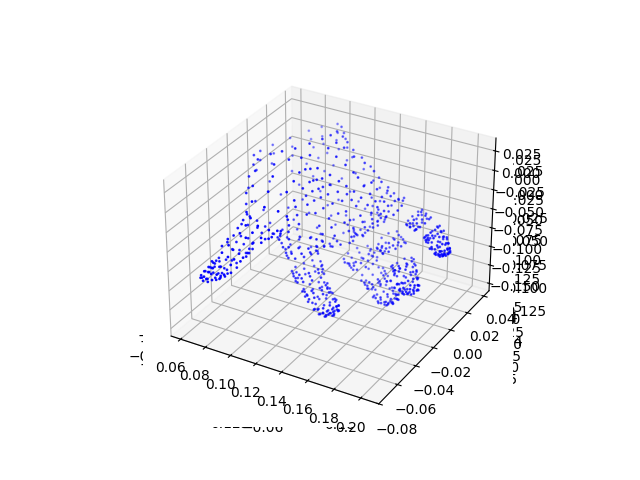

In [196]:
%matplotlib widget

mesh = output.vertices[0]
# mesh2 = targets_['mano_mesh_cam'][bx,:778]

fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')

ax3d.scatter(mesh[:,0], mesh[:,1], mesh[:,2], c='b', s=1)
# ax3d.scatter(mesh2[:,0], mesh2[:,1], mesh2[:,2], c='r')

plt.show()

# Model inference

In [3]:
import resnet

In [4]:
model: torch.nn.Module = resnet.pose_resnet50()
checkpoint = torch.load("./logs/20240828-1/checkpoint-29.pth", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint['model'])
model.to("cuda:0")
model.eval()

In [197]:
rhand_img = inputs_['rhand_img']
lhand_img = torch.flip(inputs_['lhand_img'], dims=[3])
samples = torch.concatenate([rhand_img, lhand_img], dim=0)
samples = samples.to("cuda:0")

In [198]:
pred = model(samples)

In [199]:
mano_pose_pred = eps.rearrange(pred, '(h b) j d -> h b j d', h=2)
rmano_pose_pred = mano_pose_pred[0]
lmano_pose_pred = mano_pose_pred[1]
lmano_pose_pred = torch.cat([lmano_pose_pred[:,:,0:1], -lmano_pose_pred[:,:,1:3]], dim=2)
mano_pose_pred = eps.rearrange(torch.cat([rmano_pose_pred, lmano_pose_pred], dim=1), 'b (h j) d -> b (h j d)', h=2, j=16, d=3)

In [200]:
mano_hand_pose_pred = mano_pose_pred[bx,3:48].cpu().detach()
mano_root_pose_pred = mano_pose_pred[bx,:3].cpu().detach()

output_pred = mano.layer['right'](betas=mano_shape_gt[None,:],
                                  hand_pose=mano_hand_pose_pred[None,:],
                                  global_orient=mano_root_pose_pred[None,:],
                                  transl=torch.zeros(1,3))

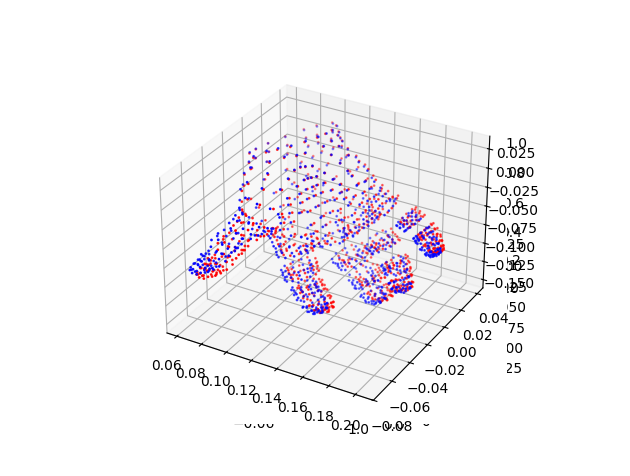

In [201]:
%matplotlib widget

mesh_pred = output_pred.vertices[0]
# mesh2 = targets_['mano_mesh_cam'][bx,:778]

fig3d = plt.figure(4)
ax3d = fig3d.add_subplot(111, projection='3d')

ax3d.scatter(mesh_pred[:,0], mesh_pred[:,1], mesh_pred[:,2], c='b', s=1)
ax3d.scatter(mesh[:,0], mesh[:,1], mesh[:,2], c='r', s=1)

plt.show()

In [98]:
pred.shape

torch.Size([8, 16, 3])

In [6]:
import einops as eps

def eval_batch(pred: torch.Tensor, targets: dict, meta_info: dict) -> list:
    mano_pose_pred = eps.rearrange(pred, '(h b) j d -> h b j d', h=2)
    rmano_pose_pred = mano_pose_pred[0]
    lmano_pose_pred = mano_pose_pred[1]
    lmano_pose_pred = torch.cat([lmano_pose_pred[:,:,0:1], -lmano_pose_pred[:,:,1:3]], dim=2)

    mano_pose_gt = targets['mano_pose']
    mano_shape_gt = targets['mano_shape']
    rmano_pose_gt = mano_pose_gt[:,:48]
    lmano_pose_gt = mano_pose_gt[:,48:]
    rmano_shape_gt = mano_shape_gt[:,:10]
    lmano_shape_gt = mano_shape_gt[:,10:]

    batch_size = mano_pose_pred.shape[1]
    rmano_pose = torch.cat([rmano_pose_pred.view(batch_size, -1), rmano_pose_gt], dim=0)
    rmano_shape = eps.repeat(rmano_shape_gt, 'b d -> (r b) d', r=2)
    lmano_pose = torch.cat([lmano_pose_pred.view(batch_size, -1), lmano_pose_gt], dim=0)
    lmano_shape = eps.repeat(lmano_shape_gt, 'b d -> (r b) d', r=2)

    r_output = mano.layer['right'](betas=rmano_shape,
                                   hand_pose=rmano_pose[:,3:],
                                   global_orient=rmano_pose[:,:3],
                                   transl=torch.zeros(batch_size*2, 3))
    l_output = mano.layer['right'](betas=lmano_shape,
                                   hand_pose=lmano_pose[:,3:],
                                   global_orient=lmano_pose[:,:3],
                                   transl=torch.zeros(batch_size*2, 3))

    rmesh_pred = r_output.vertices[:batch_size]
    rmesh_gt = r_output.vertices[batch_size:]
    lmesh_pred = l_output.vertices[:batch_size]
    lmesh_gt = l_output.vertices[batch_size:]

    rjoint_pred = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), rmesh_pred)
    rjoint_gt = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), rmesh_gt)
    ljoint_pred = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), lmesh_pred)
    ljoint_gt = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), lmesh_gt)

    mesh_pred = torch.cat([rmesh_pred, lmesh_pred], dim=1)
    mesh_gt = torch.cat([rmesh_gt, lmesh_gt], dim=1)
    joint_pred = torch.cat([rjoint_pred, ljoint_pred], dim=1)
    joint_gt = torch.cat([rjoint_gt, ljoint_gt], dim=1)

    mesh_error = ((mesh_pred - mesh_gt) ** 2).sum(-1, keepdim=True).sqrt()
    joint_error = ((joint_pred - joint_gt) ** 2).sum(-1, keepdim=True).sqrt()
    mesh_valid = meta_info['mano_mesh_valid']
    joint_valid = meta_info['joint_valid']

    return mesh_error, mesh_valid, joint_error, joint_valid

In [163]:
mesh_error, mesh_valid, joint_error, joint_valid = \
    eval_batch(pred.cpu().detach(), targets_, meta_info_)

In [169]:
mpjpe = ((joint_error * joint_valid).sum() / joint_valid.sum()).item()
mpvpe = ((mesh_error * mesh_valid).sum() / mesh_valid.sum()).item()
print(f"MPJPE: {mpjpe}\nMPVPE: {mpvpe}")

MPJPE: 0.008995001204311848
MPVPE: 0.008352294564247131


In [181]:
joint_error[joint_valid > 0.5].shape
meta_info_.keys()

dict_keys(['bb2img_trans', 'joint_valid', 'joint_trunc', 'mano_joint_trunc', 'mano_mesh_valid', 'rel_trans_valid', 'mano_pose_valid', 'mano_shape_valid', 'lhand_bbox_valid', 'rhand_bbox_valid', 'is_3D'])

In [5]:
from tqdm import tqdm

In [7]:
N = 50
mpjpe_list = []

for ix, (inputs_, targets_, meta_info_) in tqdm(enumerate(dataloader), total=len(dataloader), ncols=100):
    rhand_img = inputs_['rhand_img']
    lhand_img = torch.flip(inputs_['lhand_img'], dims=[3])
    samples = torch.concatenate([rhand_img, lhand_img], dim=0)
    samples = samples.to("cuda:0")

    with torch.no_grad():
        pred = model(samples)

    mesh_error, mesh_valid, joint_error, joint_valid = eval_batch(pred.cpu().detach(), targets_, meta_info_)
    mpjpe_list.extend(joint_error[joint_valid > 0.5].tolist()) 

    # if ix >= N:
    #     break

100%|██████████████████████████████████████████████████████| 29362/29362 [12:53:20<00:00,  1.58s/it]


In [ ]:
np.array(mpjpe_list).mean()

# Test pipeline

In [1]:
import einops as eps
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import einops as eps
from tqdm import tqdm

from dataset.InterHand26M import InterHand26M
from dataset.InterHand26M.utils.mano import mano
import resnet

Fix shapedirs bug of MANO


/home/renkaiwen/.conda/envs/sl_vit_cu118/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
transforms_test = transforms.Compose([
    transforms.Resize((224, 224))
])

dataset_train = InterHand26M(transforms_test, "test")

loading annotations into memory...
Done (t=40.39s)
creating index...
index created!


In [3]:
dataloader = torch.utils.data.DataLoader(dataset_train, batch_size=32, pin_memory=True)

In [4]:
model: torch.nn.Module = resnet.pose_resnet50()
checkpoint = torch.load("./logs/20240828-1/checkpoint-29.pth", map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint['model'])
model.to("cuda:0")
model.eval()

In [19]:
def eval_batch(pred: torch.Tensor, targets: dict, meta_info: dict) -> list:
    mano_pose_pred = eps.rearrange(pred, '(h b) j d -> h b j d', h=2)
    rmano_pose_pred = mano_pose_pred[0]
    lmano_pose_pred = mano_pose_pred[1]
    lmano_pose_pred = torch.cat([lmano_pose_pred[:,:,0:1], -lmano_pose_pred[:,:,1:3]], dim=2)

    mano_pose_gt = targets['mano_pose']
    mano_shape_gt = targets['mano_shape']
    rmano_pose_gt = mano_pose_gt[:,:48]
    lmano_pose_gt = mano_pose_gt[:,48:]
    rmano_shape_gt = mano_shape_gt[:,:10]
    lmano_shape_gt = mano_shape_gt[:,10:]

    batch_size = mano_pose_pred.shape[1]
    rmano_pose = torch.cat([rmano_pose_pred.view(batch_size, -1), rmano_pose_gt], dim=0)
    rmano_shape = eps.repeat(rmano_shape_gt, 'b d -> (r b) d', r=2)
    lmano_pose = torch.cat([lmano_pose_pred.view(batch_size, -1), lmano_pose_gt], dim=0)
    lmano_shape = eps.repeat(lmano_shape_gt, 'b d -> (r b) d', r=2)

    r_output = mano.layer['right'](betas=rmano_shape,
                                   hand_pose=rmano_pose[:,3:],
                                   global_orient=rmano_pose[:,:3],
                                   transl=torch.zeros(batch_size*2, 3))
    l_output = mano.layer['left'](betas=lmano_shape,
                                   hand_pose=lmano_pose[:,3:],
                                   global_orient=lmano_pose[:,:3],
                                   transl=torch.zeros(batch_size*2, 3))

    rmesh_pred = r_output.vertices[:batch_size]
    rmesh_gt = r_output.vertices[batch_size:]
    lmesh_pred = l_output.vertices[:batch_size]
    lmesh_gt = l_output.vertices[batch_size:]

    rjoint_pred = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), rmesh_pred)
    rjoint_gt = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), rmesh_gt)
    ljoint_pred = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), lmesh_pred)
    ljoint_gt = torch.bmm(torch.from_numpy(mano.sh_joint_regressor)[None,...].repeat(batch_size,1,1), lmesh_gt)

    mesh_pred = torch.cat([rmesh_pred, lmesh_pred], dim=1)
    mesh_gt = torch.cat([rmesh_gt, lmesh_gt], dim=1)
    joint_pred = torch.cat([rjoint_pred, ljoint_pred], dim=1)
    joint_gt = torch.cat([rjoint_gt, ljoint_gt], dim=1)

    mesh_error = ((mesh_pred - mesh_gt) ** 2).sum(-1, keepdim=True).sqrt()
    joint_error = ((joint_pred - joint_gt) ** 2).sum(-1, keepdim=True).sqrt()
    mesh_valid = meta_info['mano_mesh_valid']
    joint_valid = meta_info['joint_valid']

    return mesh_error, mesh_valid, joint_error, joint_valid

In [ ]:
mpjpe_list = []
mpvpe_sum, vertix_num = 0.0, 0

for ix, (inputs_, targets_, meta_info_) in tqdm(enumerate(dataloader), total=len(dataloader), ncols=100):
    rhand_img = inputs_['rhand_img']
    lhand_img = torch.flip(inputs_['lhand_img'], dims=[3])
    samples = torch.concatenate([rhand_img, lhand_img], dim=0)
    samples = samples.to("cuda:0")

    with torch.no_grad():
        pred = model(samples)
        mesh_error, mesh_valid, joint_error, joint_valid = eval_batch(pred.cpu().detach(), targets_, meta_info_)

    mpjpe_list.extend(joint_error[joint_valid > 0.5].tolist())
    cur_mpvpe = mesh_error[mesh_valid > 0.5]
    mpvpe_sum += cur_mpvpe.sum().item()
    vertix_num += cur_mpvpe.shape[0]

  0%|▏                                                         | 10/3671 [05:31<36:04:15, 35.47s/it]

In [17]:
cur_mpvpe.sum() / cur_mpvpe.shape[0]

tensor(0.0113)